# Trends, overlap, outliers, correlations, importance (3a - 3f)

In [1]:
import sys, glob, warnings
warnings.filterwarnings("ignore")
sys.path.append("../../") # lets us import helper.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from helper import *
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_FILE = glob.glob("../../data/student_mental_health/*.csv")[0]
TARGET = "Stress_Level"
ORDER = ["Low", "Medium", "High", "Very High"] # natural order of the classes

df = pd.read_csv(DATA_FILE)
# Allowed "datatype fix": the target is text, but it has a natural order; ordered categorical
df[TARGET] = pd.Categorical(df[TARGET], categories=ORDER, ordered=True)
num_cols, cat_cols = split_columns(df, TARGET) # feature lists WITHOUT the target
print(df.shape, "| numeric features:", len(num_cols), "| categorical features:", len(cat_cols))

(5000, 13) | numeric features: 7 | categorical features: 5


## 3a) Major Trends


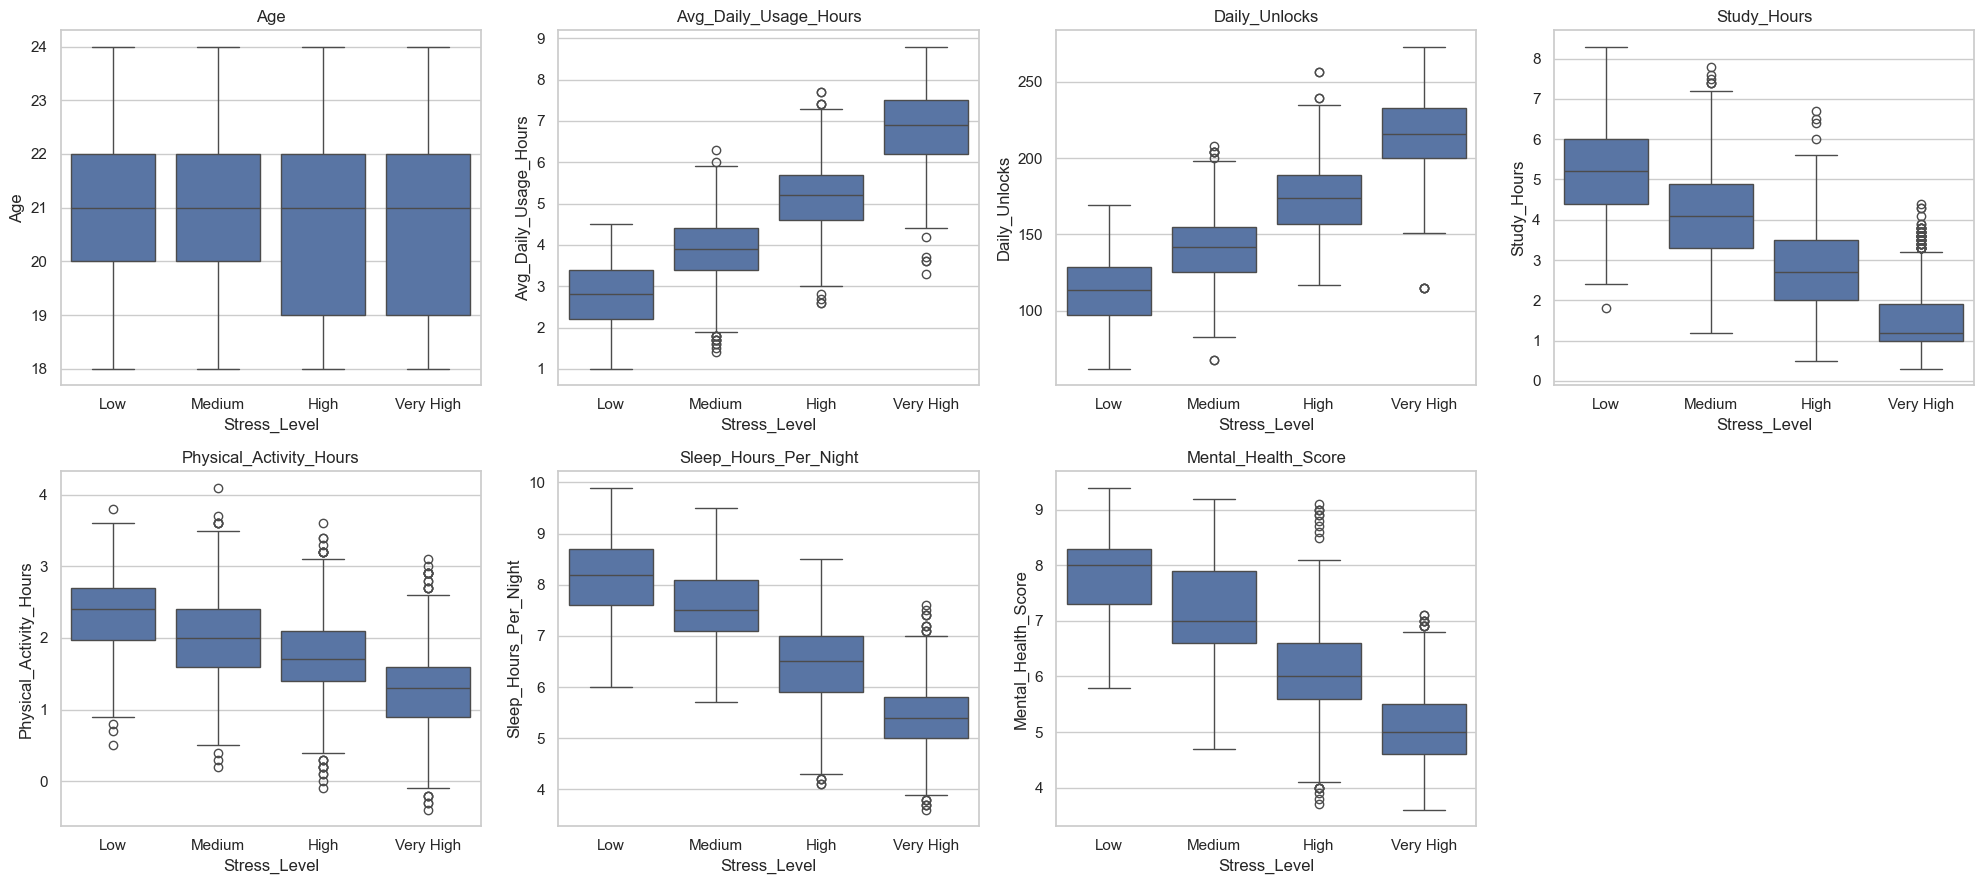

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
Stress_Level,,,,,,,
Low,21.04,2.78,113.82,5.18,2.35,8.16,7.84
Medium,21.00,3.86,141.01,4.12,2.05,7.57,7.14
High,20.70,5.19,173.98,2.75,1.73,6.45,6.03
Very High,20.70,6.87,216.42,1.49,1.29,5.44,5.05


In [2]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x=TARGET, y=col, order=ORDER, ax=ax); ax.set_title(col)
axes.ravel()[-1].axis("off"); plt.tight_layout(); plt.show()
display(df.groupby(TARGET, observed=True)[num_cols].mean().round(2))

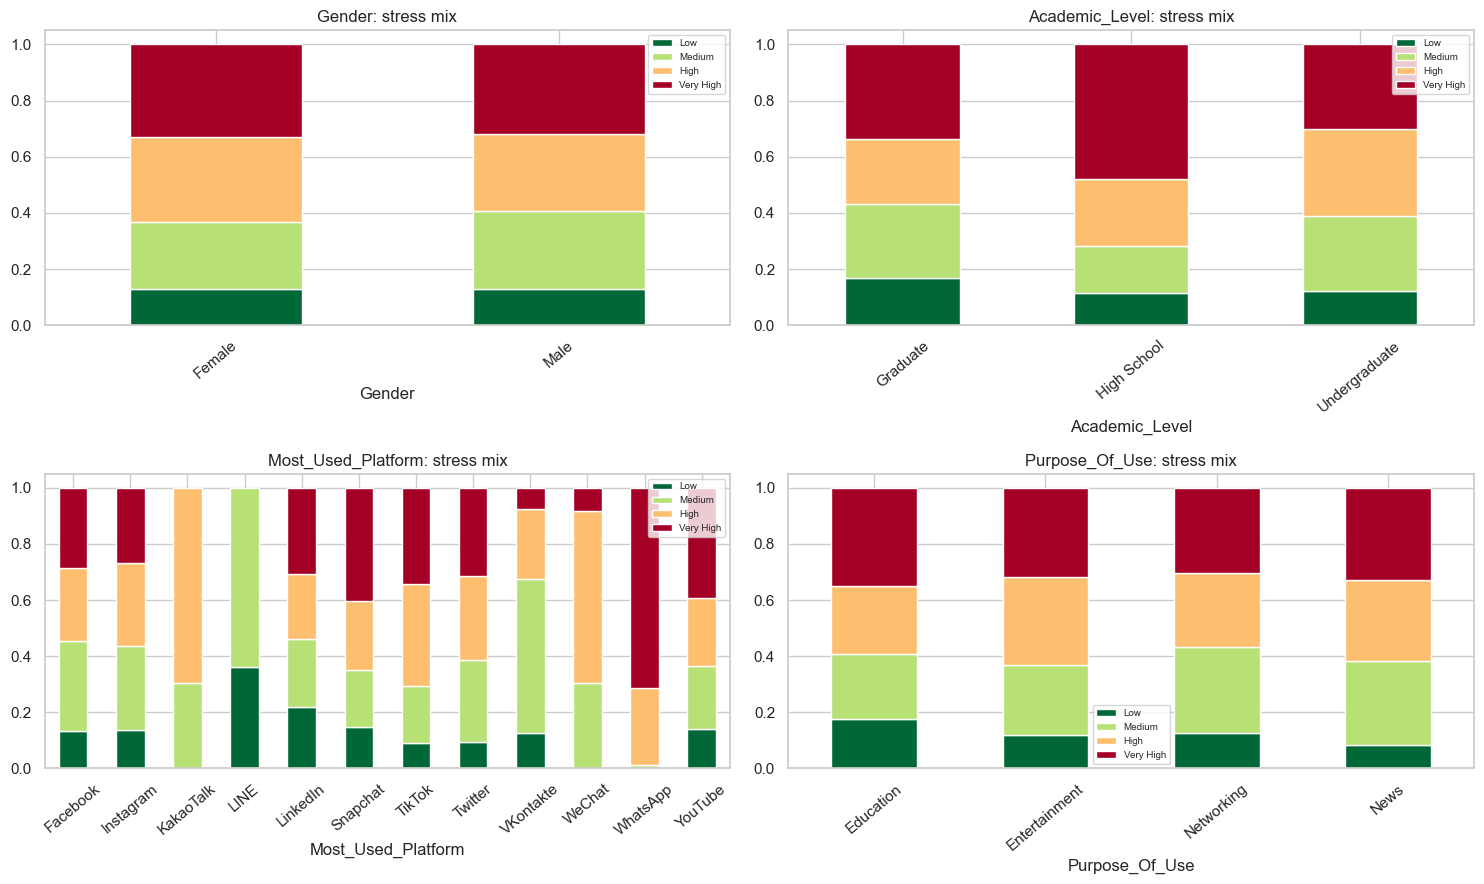

In [3]:
# categorical features vs target: share of each stress class inside each category
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.ravel(), [c for c in cat_cols if c != "Country"]):
    pd.crosstab(df[col], df[TARGET], normalize="index")[ORDER].plot.bar(stacked=True, ax=ax, colormap="RdYlGn_r")
    ax.set_title(f"{col}: stress mix"); ax.tick_params(axis="x", rotation=40); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3b) Overlapping data

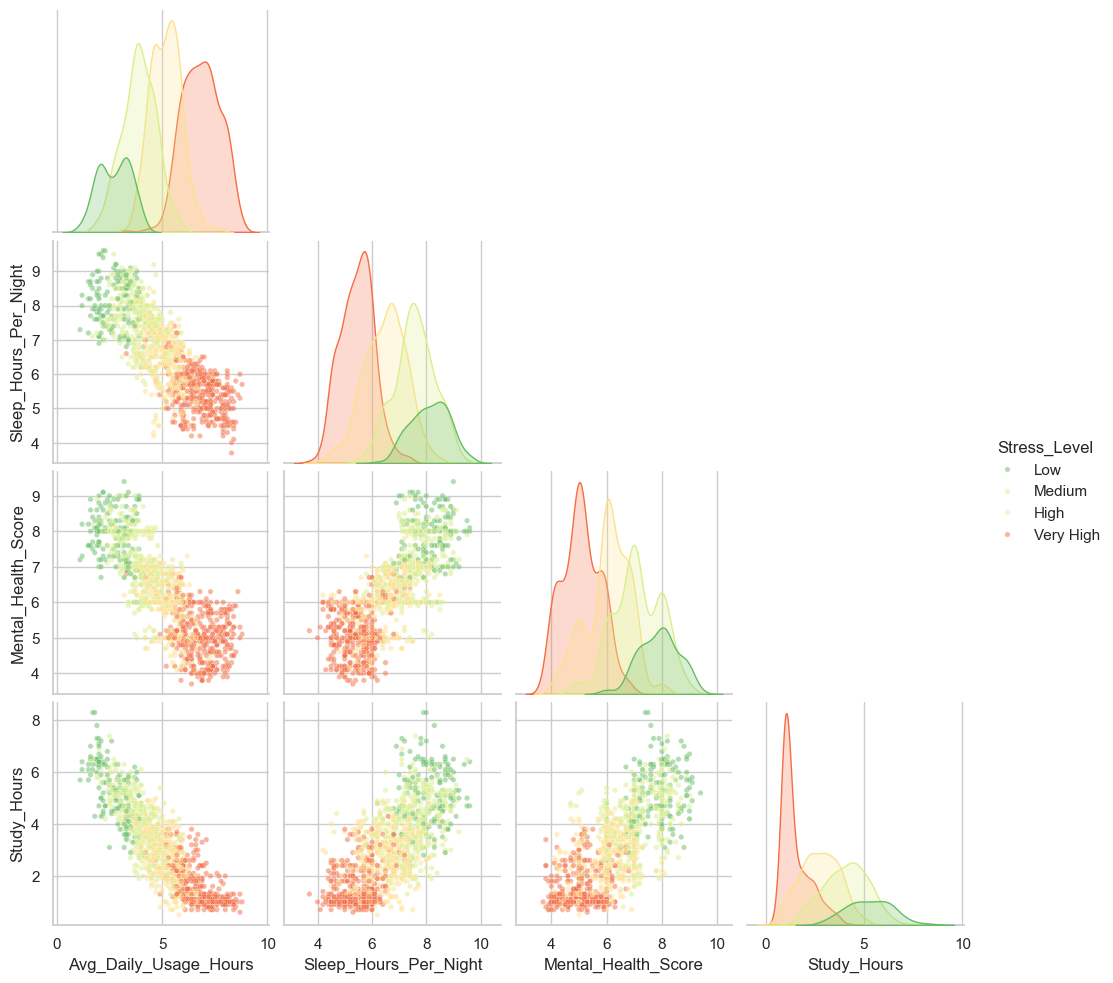

Stress_Level,Low,Medium,High,Very High
Avg_Daily_Usage_Hours,,,,
"(0, 2]",130,23,0,0
"(2, 3]",254,183,5,0
"(3, 4]",247,566,79,4
"(4, 5]",13,452,535,10
"(5, 6]",0,70,658,276
"(6, 7]",0,1,152,651
"(7, 9]",0,0,11,680


In [4]:
sample = df.sample(1200, random_state=1)
sns.pairplot(sample, vars=["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Mental_Health_Score", "Study_Hours"],
             hue=TARGET, hue_order=ORDER, palette="RdYlGn_r", plot_kws={"alpha": .5, "s": 15}, corner=True)
plt.show()
bins = pd.cut(df["Avg_Daily_Usage_Hours"], [0, 2, 3, 4, 5, 6, 7, 9])
display(pd.crosstab(bins, df[TARGET])[ORDER])

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(5, shuffle=True, random_state=42)
y_codes = df[TARGET].cat.codes
for feats in (["Avg_Daily_Usage_Hours"], ["Avg_Daily_Usage_Hours", "Mental_Health_Score", "Sleep_Hours_Per_Night"], num_cols):
    acc = cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=0), df[feats], y_codes, cv=cv).mean()
    print(f"depth-3 tree using {len(feats)} feature(s) {feats[:2]}...  accuracy = {acc:.3f}")
print("Always predicting the biggest class would score:", round(df[TARGET].value_counts(normalize=True).max(), 3))

depth-3 tree using 1 feature(s) ['Avg_Daily_Usage_Hours']...  accuracy = 0.705
depth-3 tree using 3 feature(s) ['Avg_Daily_Usage_Hours', 'Mental_Health_Score']...  accuracy = 0.710
depth-3 tree using 7 feature(s) ['Age', 'Avg_Daily_Usage_Hours']...  accuracy = 0.710
Always predicting the biggest class would score: 0.324


## 3c) Outliers and Noise

,n_outliers,pct,lower_fence,upper_fence,min,max,n_|z|>3,n_MAD_outliers
column,,,,,,,,
Age,0,0.00,14.50,26.50,18.0,24.0,0,0.0
Avg_Daily_Usage_Hours,0,0.00,0.05,10.05,1.0,8.8,0,0.0
Daily_Unlocks,0,0.00,44.00,300.00,62.0,273.0,0,0.0
Study_Hours,2,0.04,-2.55,8.25,0.3,8.3,3,0.0
Physical_Activity_Hours,22,0.44,-0.05,3.55,-0.4,4.1,5,0.0
Sleep_Hours_Per_Night,0,0.00,2.75,10.35,3.6,9.9,0,0.0
Mental_Health_Score,0,0.00,2.10,10.10,3.6,9.4,0,0.0


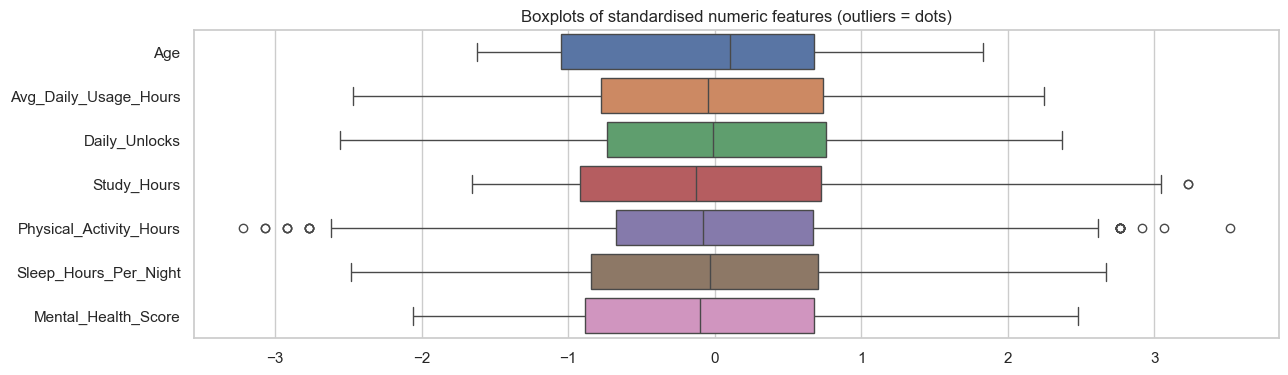

In [6]:
res = iqr_outliers(df, num_cols).join(zscore_outliers(df, num_cols)).join(mad_outliers(df, num_cols))
display(res[["n_outliers", "pct", "lower_fence", "upper_fence", "min", "max", "n_|z|>3", "n_MAD_outliers"]])
plt.figure(figsize=(14, 4)); sns.boxplot(data=(df[num_cols]-df[num_cols].mean())/df[num_cols].std(), orient="h")
plt.title("Boxplots of standardised numeric features (outliers = dots)"); plt.show()

In [7]:
out = pd.DataFrame({"isolation_forest": isolation_forest_flags(df, num_cols), "elliptic_envelope": elliptic_flags(df, num_cols)})
print(out.sum(), "\nflagged by BOTH:", int(out.all(axis=1).sum()))
display(df[out.all(axis=1)].head(10))
neg = df["Physical_Activity_Hours"] < 0
print("Negative-activity rows also flagged by a multivariate method:", int((neg & out.any(axis=1)).sum()), "of", int(neg.sum()))

isolation_forest     100
elliptic_envelope    100
dtype: int64 
flagged by BOTH: 23


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
60,24,Male,Other,Graduate,Instagram,Entertainment,1.7,104,7.4,2.6,7.7,Low,8.7
190,24,Female,Other,Graduate,Facebook,Networking,1.5,62,5.7,1.4,7.2,Low,7.6
443,18,Male,Other,High School,Snapchat,Entertainment,2.3,102,7.6,3.2,7.5,Medium,8.2
541,23,Female,India,Graduate,Twitter,News,1.7,68,5.8,3.2,7.0,Medium,8.9
543,18,Male,Canada,High School,Twitter,News,1.9,84,6.7,2.0,7.3,Medium,8.9
691,22,Male,Other,Undergraduate,TikTok,Entertainment,1.6,70,7.8,3.1,7.7,Low,7.8
765,18,Male,Other,High School,Twitter,News,2.4,86,6.6,1.6,7.3,Low,8.4
789,20,Male,Other,Undergraduate,Snapchat,Entertainment,2.0,102,6.7,3.2,7.1,Low,9.0
894,23,Female,Other,Graduate,LinkedIn,Education,1.8,107,8.0,2.6,8.2,Low,7.2
2121,24,Male,Sweden,Graduate,LinkedIn,Education,1.9,112,7.2,3.2,8.3,Low,8.1


Negative-activity rows also flagged by a multivariate method: 5 of 10


# 3d) Correlations and Phi-K associations

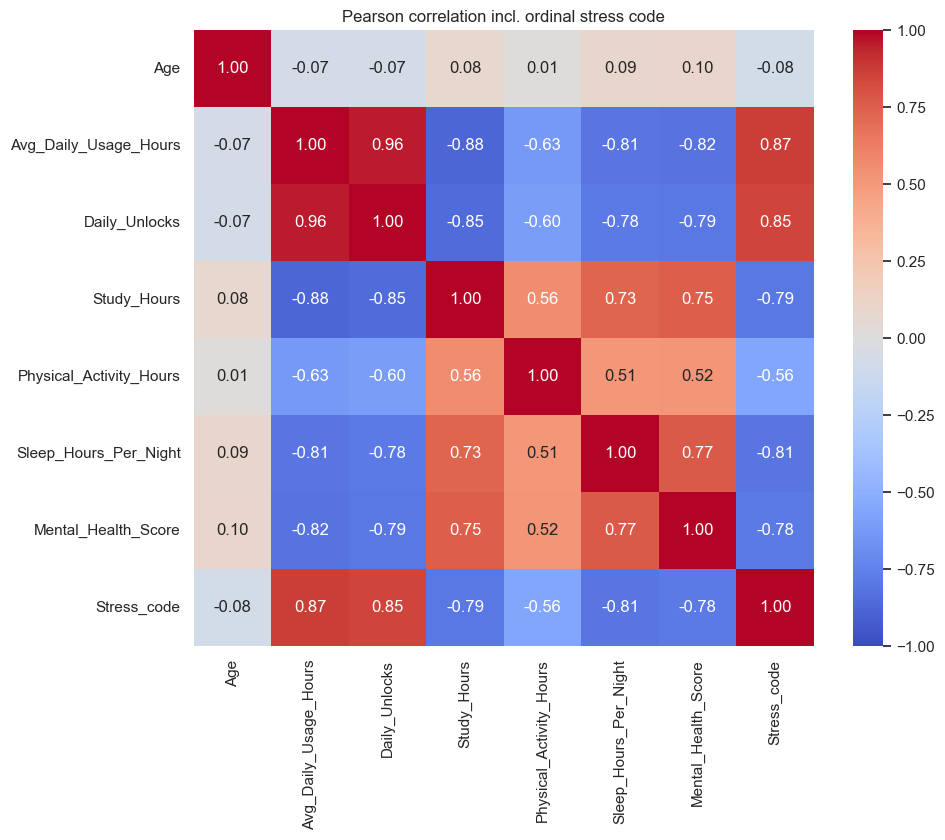

,corr with stress
Avg_Daily_Usage_Hours,0.873
Daily_Unlocks,0.845
Sleep_Hours_Per_Night,-0.811
Study_Hours,-0.795
Mental_Health_Score,-0.783
Physical_Activity_Hours,-0.556
Age,-0.078


In [8]:
work = df.copy(); work["Stress_code"] = df[TARGET].cat.codes          # 0=Low ... 3=Very High, only for correlation
corr = work[num_cols + ["Stress_code"]].corr()
plt.figure(figsize=(10, 8)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson correlation incl. ordinal stress code"); plt.show()
display(corr["Stress_code"].drop("Stress_code").sort_values(key=abs, ascending=False).round(3).to_frame("corr with stress"))

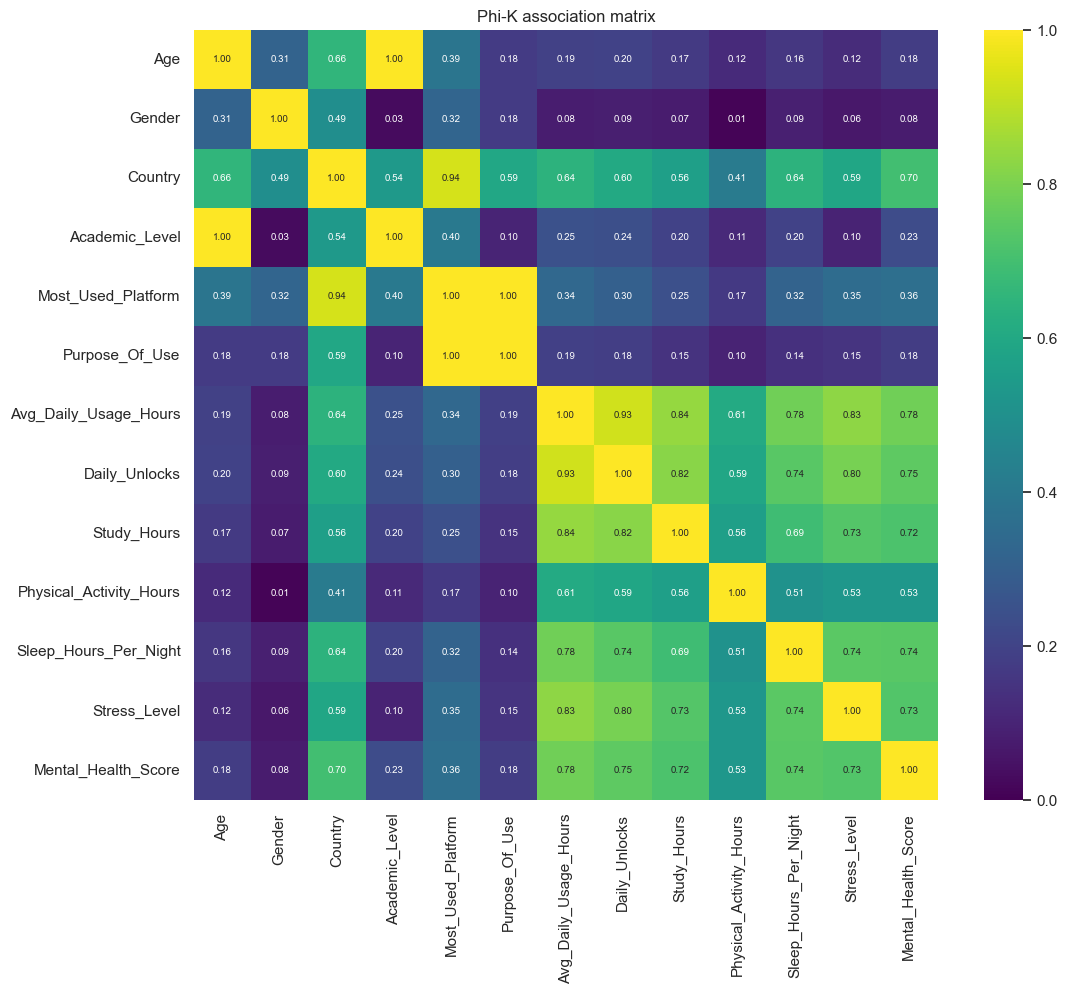

,Phi-K with Stress_Level
Avg_Daily_Usage_Hours,0.832
Daily_Unlocks,0.796
Sleep_Hours_Per_Night,0.744
Study_Hours,0.732
Mental_Health_Score,0.727
Country,0.590
Physical_Activity_Hours,0.527
Most_Used_Platform,0.352
Purpose_Of_Use,0.152
Age,0.122


In [9]:
pk, method = association_matrix(df.drop(columns=[]), interval_cols=num_cols)
plt.figure(figsize=(12, 10)); sns.heatmap(pk, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, annot_kws={"size": 7})
plt.title(f"{method} association matrix"); plt.show()
display(pk[TARGET].drop(TARGET).sort_values(ascending=False).round(3).to_frame(f"{method} with {TARGET}"))

## 3e) Feature importance

Dropped for being high-cardinality: ['Country'] | matrix shape: (5000, 28)


,ANOVA_F,mutual_info,RF_importance,RFE_rank
Avg_Daily_Usage_Hours,5579.598,0.723,0.215,1
Daily_Unlocks,4316.536,0.678,0.190,1
Sleep_Hours_Per_Night,3330.803,0.529,0.139,1
Mental_Health_Score,2685.017,0.486,0.117,2
Study_Hours,2870.741,0.467,0.110,8
Physical_Activity_Hours,756.253,0.193,0.073,18
Age,12.597,0.014,0.036,12
Gender_Male,4.015,0.000,0.011,19
Gender_Female,4.015,0.013,0.011,22
Most_Used_Platform_TikTok,16.384,0.001,0.009,17


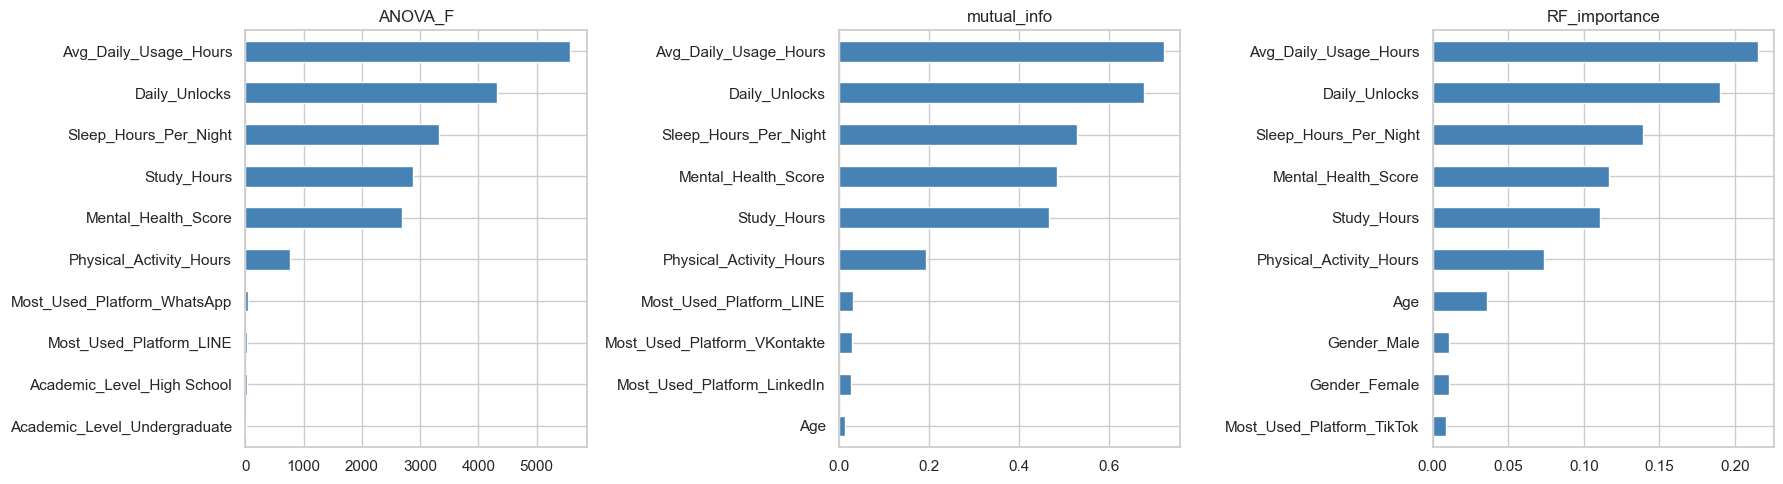

In [10]:
from sklearn.feature_selection import f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X, y, dropped = make_model_matrix(df, TARGET)
y = y.cat.codes
print("Dropped for being high-cardinality:", dropped, "| matrix shape:", X.shape)

imp = pd.DataFrame({
    "ANOVA_F": f_classif(X, y)[0],
    "mutual_info": mutual_info_classif(X, y, random_state=42),
    "RF_importance": RandomForestClassifier(300, random_state=42, n_jobs=-1).fit(X, y).feature_importances_,
}, index=X.columns)
imp["RFE_rank"] = RFE(LogisticRegression(max_iter=3000), n_features_to_select=5).fit(StandardScaler().fit_transform(X), y).ranking_
imp = imp.sort_values("RF_importance", ascending=False)
display(imp.round(3).head(15))

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, col in zip(ax, ["ANOVA_F", "mutual_info", "RF_importance"]):
    imp[col].sort_values().tail(10).plot.barh(ax=a, color="steelblue"); a.set_title(col)
plt.tight_layout(); plt.show()

In [11]:
# Sanity check: how much does the model need the "suspicious" Mental_Health_Score?
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rf = RandomForestClassifier(200, random_state=42, n_jobs=-1)
for name, cols in {"all numeric features": num_cols,
                   "without Mental_Health_Score": [c for c in num_cols if c != "Mental_Health_Score"],
                   "usage + unlocks only": ["Avg_Daily_Usage_Hours", "Daily_Unlocks"]}.items():
    print(f"{name:32s} accuracy = {cross_val_score(rf, df[cols], y, cv=cv).mean():.3f}")

all numeric features             accuracy = 0.836
without Mental_Health_Score      accuracy = 0.839
usage + unlocks only             accuracy = 0.701


## 3f) Other potentional Problems